In [1]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.figsize'] = (20.0, 10.0)

Load Last 7 days of CSV Stats from S3 Bucket for processing

In [2]:
stats = pd.DataFrame()
list_ = []
for x in range(1,8):
    yesterday = datetime.now() - timedelta(days=x)
    str_stats = '{}_{}_{}'.format(yesterday.year,yesterday.month,yesterday.day)
    url = 'https://s3.us-east-2.amazonaws.com/notebooks-esri-com/stats/{}.csv'.format(str_stats)
    #print(url)
    try:
        df = pd.read_csv('https://s3.us-east-2.amazonaws.com/notebooks-esri-com/stats/{}.csv'.format(str_stats),
                     names=['Hour', 'Requests', 'UniqueIPs', 'WS'])
    except:
        continue
    list_.append(df)
stats = pd.concat(list_)
stats['Hour'] = pd.to_datetime(stats['Hour'],  format="%Y%m%dT%H")
stats = stats.sort_values(['Hour'])
stats.set_index('Hour',  inplace=True)

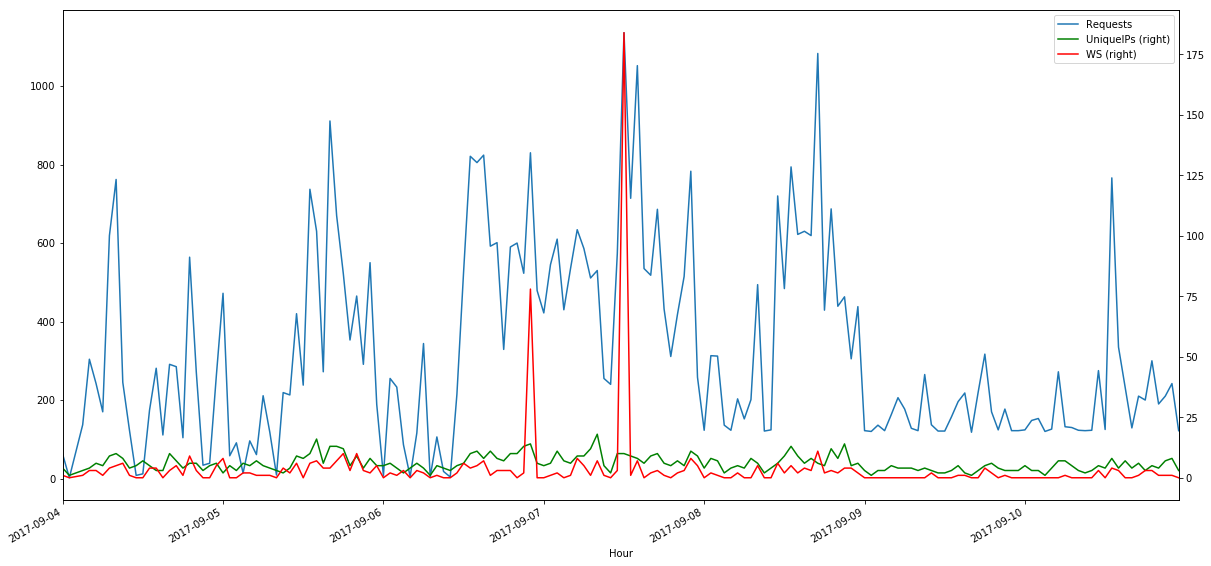

In [3]:
plt.figure()
stats.Requests.plot(legend=True)
stats.UniqueIPs.plot(secondary_y=True, legend=True, style='g')
stats.WS.plot(secondary_y=True, legend=True, style='r')
plt.show()